# AdaBoost Classifier: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **AdaBoost Classifier** in Python.

### Concept Overview
An adaptive boosting ensemble method that fits sequential weak learners (stumps) by updating weights on previously misclassified points.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
H(\mathbf{x}) = \text{sign} \left( \sum_{t=1}^T \alpha_t h_t(\mathbf{x}) \right) \quad \text{where } \alpha_t \text{ is weak learner voting power}
$$

### Real-World Analogy
**Analogy:** A teacher giving extra homework and attention to topics that students got wrong on the last exam.

### Worked Example
**Worked Example:** Telecom churn classification. AdaBoost trains a decision stump (depth 1 tree). Stumps that classify churn incorrectly are assigned higher weights. The next stump focuses on these hard cases.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of customer churn profiles
from sklearn.datasets import make_classification
np.random.seed(42)
X_raw, y_raw = make_classification(n_samples=500, n_features=3, n_informative=3,
                                  n_redundant=0, n_classes=2, weights=[0.75, 0.25],
                                  class_sep=1.2, random_state=42)
df = pd.DataFrame({
    'Tenure': np.round(np.clip(X_raw[:, 0] * 15 + 24, 1, 72), 0).astype(int),
    'MonthlyCharges': np.round(X_raw[:, 1] * 25 + 70, 2),
    'UsageVolume': np.round(np.clip(X_raw[:, 2] * 100 + 300, 10, 1000), 0),
    'Churned': y_raw
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (500, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tenure          500 non-null    int64  
 1   MonthlyCharges  500 non-null    float64
 2   UsageVolume     500 non-null    float64
 3   Churned         500 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 15.8 KB
           Tenure  MonthlyCharges  UsageVolume     Churned
count  500.000000      500.000000   500.000000  500.000000
mean    17.560000       49.206620   322.854000    0.252000
std     17.730854       28.874583   157.564812    0.434596
min      1.000000      -25.260000    10.000000    0.000000
25%      4.000000       30.902500   195.750000    0.000000
50%     10.000000       48.200000   351.000000    0.000000
75%     28.000000       66.080000   434.750000    1.000000
max     72.000000      145.910000   759.000000    1.000000


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 Tenure            0
MonthlyCharges    0
UsageVolume       0
Churned           0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We visualize the distributions and correlations of features.

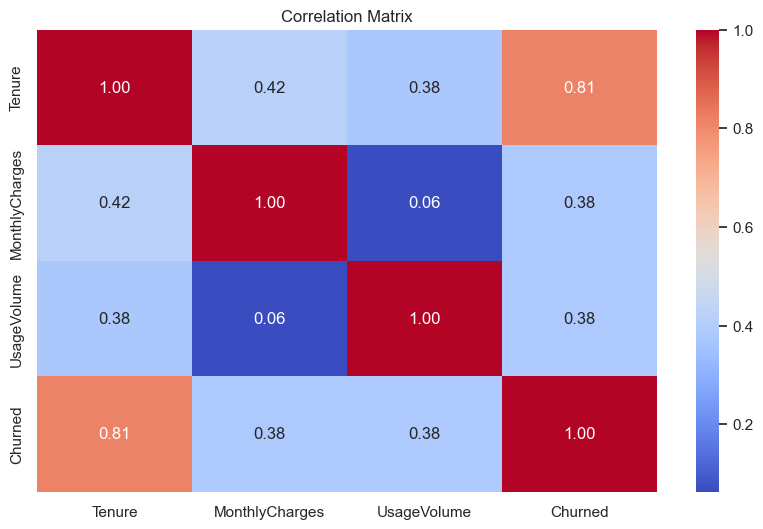

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print('Scaling not strictly needed for this model.')

Scaling not strictly needed for this model.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (350, 3), Test size: (150, 3)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
print("AdaBoost ensemble trained successfully.")

AdaBoost ensemble trained successfully.

## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))

Accuracy: 0.96
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       118
           1       0.93      0.88      0.90        32

    accuracy                           0.96       150
   macro avg       0.95      0.93      0.94       150
weighted avg       0.96      0.96      0.96       150



## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

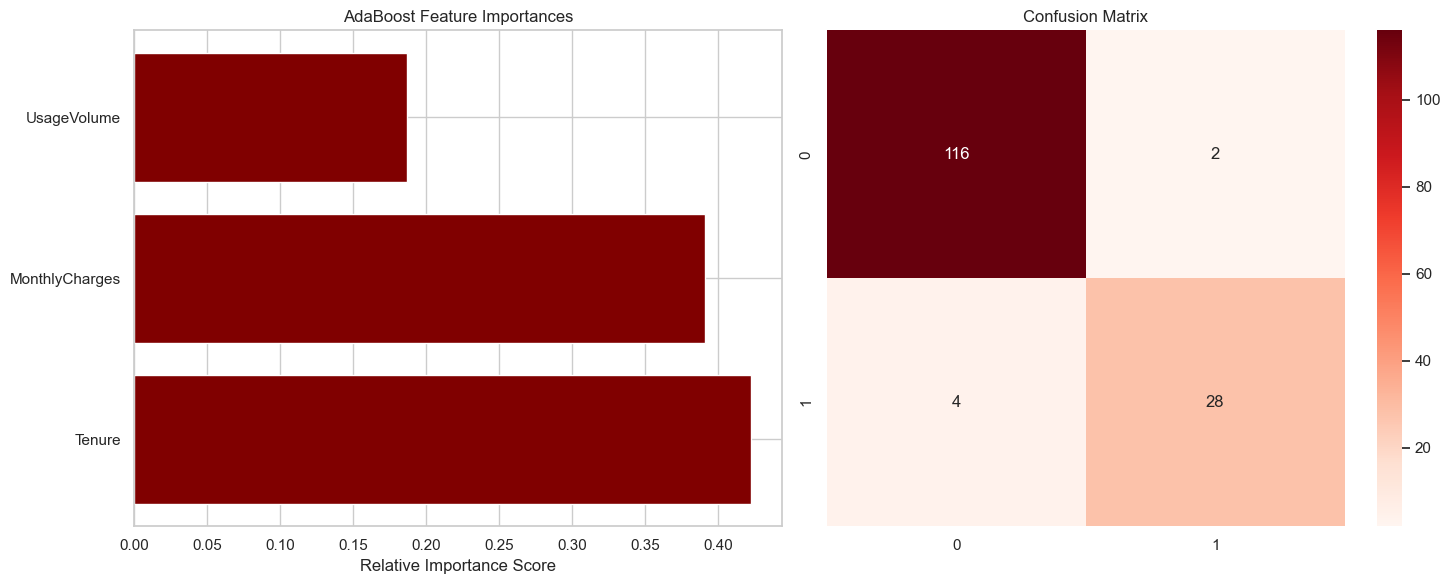

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Feature Importances
importances = model.feature_importances_
axes[0].barh(X.columns, importances, color='maroon')
axes[0].set_title("AdaBoost Feature Importances")
axes[0].set_xlabel("Relative Importance Score")

# Plot 2: Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What is a weak learner?**

*A: A simple classifier that performs slightly better than random guessing (e.g., a Decision Stump — a decision tree with a depth of 1).*

**Q2: How does AdaBoost compute learner weights (alpha)?**

*A: Based on their classification error: alpha = 0.5 * ln((1 - error) / error). Stumps with lower error get higher voting weight.*

**Q3: Why is AdaBoost sensitive to noisy data and outliers?**

*A: Because it dynamically increases the weights of misclassified points. Outliers will continuously get misclassified, forcing the model to focus heavily on fitting them (causing overfitting).*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What does 'AdaBoost' stand for?**

*A: Adaptive Boosting.*

**Q2: What is the default base estimator in scikit-learn's AdaBoost?**

*A: DecisionTreeClassifier with `max_depth=1` (a Decision Stump).*

**Q3: How are final predictions made?**

*A: By combining the predictions of all stumps using a weighted majority vote.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.